<a href="https://colab.research.google.com/github/JSEFERINO/DISE-O2026/blob/main/DISE%C3%91O2026PARTE1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Diseño de Experimentos**

# **1. Diseño de Experimentos 2026 con R y Python - P1**

## **https://rpubs.com/jseferino/DOEP1**


<a name="inicio"></a>


## **1.** [4.5. EJEMPLO DE LA EMBOTELLADORA -Código en R](#T1)
## **2.** [4.7. Simulación del Teorema del Límite Central](#T2)

## **3.** [5.3. INTERVALOS DE CONFIANZA PARA LA MEDIA](#T3)


[⬆️ Volver al inicio](#inicio)

<a name="T1"></a>
## **4.5. EJEMPLO DE LA EMBOTELLADORA**


In [ ]:
# @title **A. Librerias para Trabar en R**
import rpy2.rinterface_lib.callbacks as rcb
import logging

# Desactivar warnings de R en Python
rcb.logger.setLevel(logging.ERROR)  # Solo muestra errores, no warnings
%load_ext rpy2.ipython

(a) P(|Xbar - mu| <= 0.3) = 0.6319 
(b) Tamaño de muestra necesario: 43 



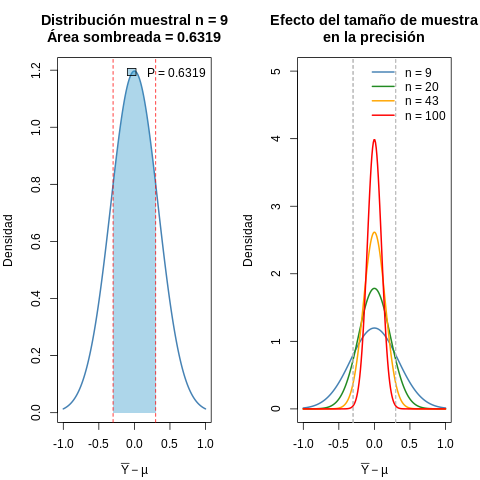

In [ ]:
# @title **B. Código en R**
# ============================================
# EJEMPLO DE LA EMBOTELLADORA
# Distribución muestral de la media
# ============================================
%%R
# Parámetros
sigma <- 1
n <- 9
error <- 0.3

# (a) Probabilidad de que |Xbar - mu| <= 0.3
# La distribución de Xbar es N(mu, sigma^2/n)
# La variable tipificada Z = (Xbar - mu)/(sigma/sqrt(n))

z_value <- error / (sigma / sqrt(n))
prob_a <- pnorm(z_value) - pnorm(-z_value)
cat("(a) P(|Xbar - mu| <= 0.3) =", round(prob_a, 4), "\n")

# (b) Tamaño de muestra necesario
confianza <- 0.95
z_alpha_2 <- qnorm((1 + confianza)/2)  # 1.96 para 95%
n_required <- (z_alpha_2 * sigma / error)^2
cat("(b) Tamaño de muestra necesario:", ceiling(n_required), "\n\n")

# ============================================
# VISUALIZACIÓN DE LA DISTRIBUCIÓN MUESTRAL
# ============================================

# Para n = 9
mu <- 0  # Centramos en 0 para visualizar la desviación
x_vals <- seq(-1, 1, length.out = 200)
densidad <- dnorm(x_vals, mean = mu, sd = sigma/sqrt(9))

# Región de aceptación (|Xbar - mu| <= 0.3)
x_fill <- seq(-0.3, 0.3, length.out = 100)
y_fill <- dnorm(x_fill, mean = mu, sd = sigma/sqrt(9))

# Gráfico
par(mfrow = c(1, 2), mar = c(4, 4, 4, 2))

# Gráfico 1: n = 9
plot(x_vals, densidad, type = "l", lwd = 2, col = "steelblue",
     xlab = expression(bar(Y) - mu), ylab = "Densidad",
     main = paste("Distribución muestral n = 9\nÁrea sombreada =", round(prob_a, 4)))
polygon(c(x_fill, rev(x_fill)), c(y_fill, rep(0, length(x_fill))),
        col = rgb(0.2, 0.6, 0.8, 0.4), border = NA)
abline(v = c(-0.3, 0.3), lty = 2, col = "red")
legend("topright", legend = paste("P =", round(prob_a, 4)),
       fill = rgb(0.2, 0.6, 0.8, 0.4), bty = "n")

# Gráfico 2: Comparación de tamaños de muestra
n_values <- c(9, 20, 43, 100)
colors <- c("steelblue", "forestgreen", "orange", "red")
plot(0, 0, type = "n", xlim = c(-1, 1), ylim = c(0, 5),
     xlab = expression(bar(Y) - mu), ylab = "Densidad",
     main = "Efecto del tamaño de muestra\nen la precisión")

for (i in 1:length(n_values)) {
  x <- seq(-1, 1, length.out = 200)
  y <- dnorm(x, mean = 0, sd = sigma/sqrt(n_values[i]))
  lines(x, y, col = colors[i], lwd = 2)
  # Marcar región de error
  abline(v = c(-0.3, 0.3), lty = 2, col = "gray")
}
legend("topright", legend = paste("n =", n_values),
       col = colors, lwd = 2, bty = "n")


(a) P(|Xbar - mu| <= 0.3) = 0.6319
(b) Tamaño de muestra necesario: 43


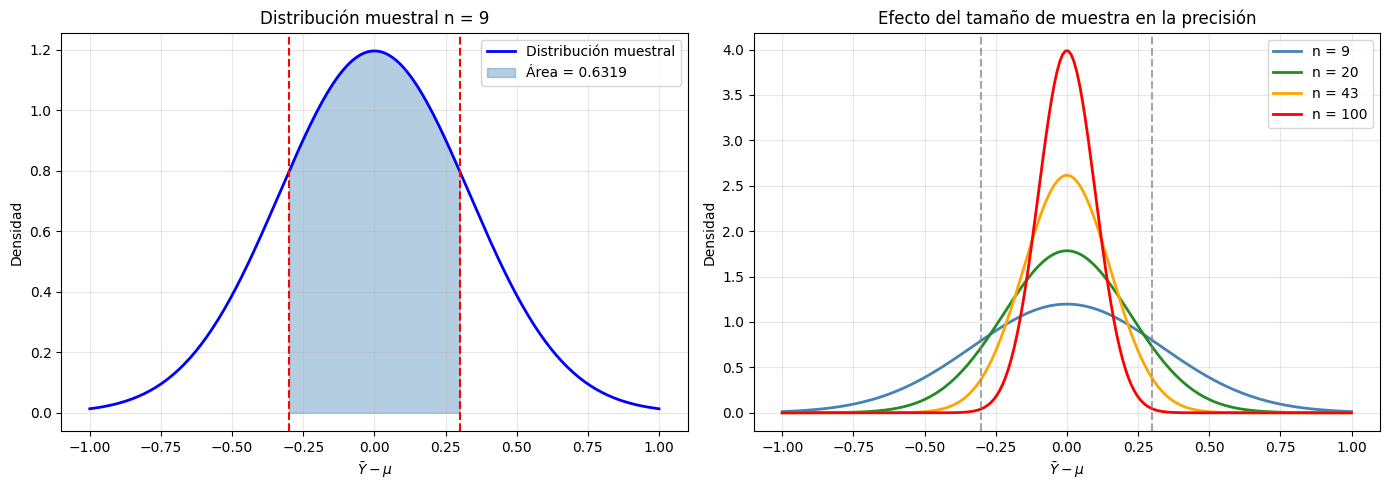

In [ ]:

#@title **📌 C. Ejemplo con Visualización en Python**


# ============================================
# EJEMPLO DE LA EMBOTELLADORA
# Distribución muestral de la media
# ============================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Parámetros
sigma = 1
n = 9
error = 0.3

# (a) Probabilidad de que |Xbar - mu| <= 0.3
z_value = error / (sigma / np.sqrt(n))
prob_a = norm.cdf(z_value) - norm.cdf(-z_value)
print(f"(a) P(|Xbar - mu| <= 0.3) = {prob_a:.4f}")

# (b) Tamaño de muestra necesario
confianza = 0.95
z_alpha_2 = norm.ppf((1 + confianza)/2)  # 1.96 para 95%
n_required = (z_alpha_2 * sigma / error)**2
print(f"(b) Tamaño de muestra necesario: {int(np.ceil(n_required))}")

# ============================================
# VISUALIZACIÓN DE LA DISTRIBUCIÓN MUESTRAL
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: n = 9
mu = 0  # Centramos en 0 para visualizar la desviación
x_vals = np.linspace(-1, 1, 200)
densidad = norm.pdf(x_vals, loc=mu, scale=sigma/np.sqrt(9))

axes[0].plot(x_vals, densidad, 'b-', lw=2, label='Distribución muestral')
# Región de aceptación
x_fill = np.linspace(-0.3, 0.3, 100)
y_fill = norm.pdf(x_fill, loc=mu, scale=sigma/np.sqrt(9))
axes[0].fill_between(x_fill, y_fill, alpha=0.4, color='steelblue',
                      label=f'Área = {prob_a:.4f}')
axes[0].axvline(-0.3, color='red', linestyle='--')
axes[0].axvline(0.3, color='red', linestyle='--')
axes[0].set_xlabel(r'$\bar{Y} - \mu$')
axes[0].set_ylabel('Densidad')
axes[0].set_title(f'Distribución muestral n = 9')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Gráfico 2: Comparación de tamaños de muestra
n_values = [9, 20, 43, 100]
colors = ['steelblue', 'forestgreen', 'orange', 'red']

for i, n_val in enumerate(n_values):
    x = np.linspace(-1, 1, 200)
    y = norm.pdf(x, loc=0, scale=sigma/np.sqrt(n_val))
    axes[1].plot(x, y, color=colors[i], lw=2, label=f'n = {n_val}')

axes[1].axvline(-0.3, color='gray', linestyle='--', alpha=0.7)
axes[1].axvline(0.3, color='gray', linestyle='--', alpha=0.7)
axes[1].set_xlabel(r'$\bar{Y} - \mu$')
axes[1].set_ylabel('Densidad')
axes[1].set_title('Efecto del tamaño de muestra en la precisión')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


[⬆️ Volver al inicio](#inicio)

<a name="T2"></a>
## **4.7. SIMULACIÓN DEL TEOREMA DEL LÍMITE CENTRAL**


In [ ]:
#@title **A. Librerias para Trabar en R**
import rpy2.rinterface_lib.callbacks as rcb
import logging

# Desactivar warnings de R en Python
rcb.logger.setLevel(logging.ERROR)  # Solo muestra errores, no warnings
%load_ext rpy2.ipython


The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


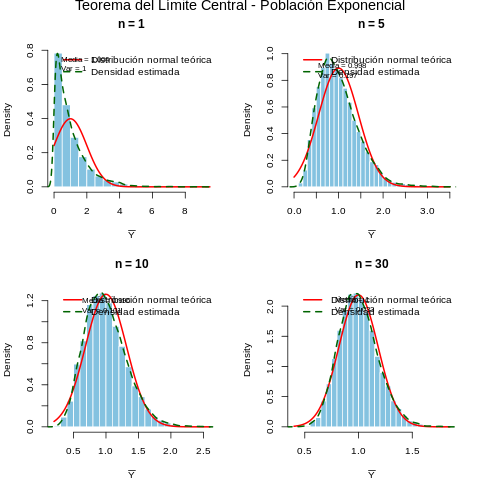

In [ ]:

%%R
# ============================================
# @title **B. SIMULACIÓN DEL TEOREMA DEL LÍMITE CENTRAL en R**
# Población no normal (distribución exponencial)
# ============================================

# Configuración de la simulación
set.seed(123)
n_simulaciones <- 10000
n_muestras <- c(1, 5, 10, 30)  # Diferentes tamaños de muestra

# Función para generar medias muestrales
generar_medias <- function(n, n_sim, lambda = 1) {
  replicas <- replicate(n_sim, mean(rexp(n, rate = lambda)))
  return(replicas)
}

# Parámetro de la exponencial
lambda <- 1  # media = 1, varianza = 1
mu_poblacional <- 1/lambda
sigma_poblacional <- 1/lambda

# Crear gráficos
par(mfrow = c(2, 2), mar = c(4, 4, 4, 2))

for (n in n_muestras) {
  # Generar medias muestrales
  medias <- generar_medias(n, n_simulaciones, lambda)

  # Histograma
  hist(medias, breaks = 30, prob = TRUE,
       main = paste("n =", n),
       xlab = expression(bar(Y)),
       col = rgb(0.2, 0.6, 0.8, 0.6),
       border = "white")

  # Superponer curva normal teórica
  # x_vals <- seq(min(medias), max(medias), length.out = 100) # This line is not needed for curve()
  curve(dnorm(x, mean = mu_poblacional,
              sd = sigma_poblacional/sqrt(n)),
        add = TRUE, col = "red", lwd = 2)

  # Superponer densidad estimada
  lines(density(medias), col = "darkgreen", lwd = 2, lty = 2)

  legend("topright",
         legend = c("Distribución normal teórica", "Densidad estimada"),
         col = c("red", "darkgreen"), lwd = 2, lty = c(1, 2), bty = "n")

  # Agregar texto con media y varianza
  text(x = quantile(medias, 0.05),
       y = max(hist(medias, plot = FALSE)$density) * 0.9,
       labels = paste("Media =", round(mean(medias), 3),
                      "\nVar =", round(var(medias), 3)),
       cex = 0.8, pos = 4)
}

# Título general
mtext("Teorema del Límite Central - Población Exponencial",
      outer = TRUE, cex = 1.2, line = -1)


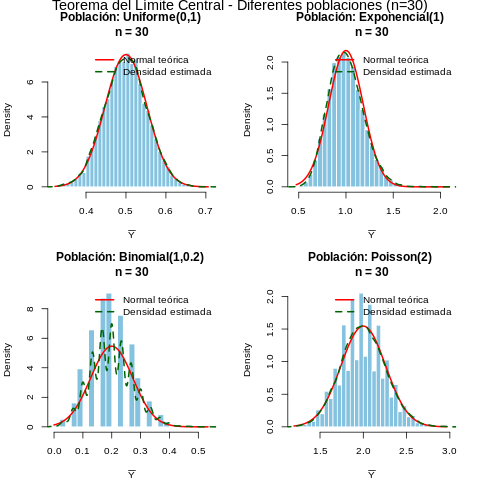

In [ ]:

%%R
# ============================================
# @title **C. COMPARACIÓN CON DIFERENTES POBLACIONES**
# ============================================

# Funciones para generar diferentes distribuciones
generar_poblacion <- function(n, tipo, n_sim = 10000) {
  if (tipo == "uniforme") {
    datos <- replicate(n_sim, mean(runif(n, min = 0, max = 1)))
    mu <- 0.5; sigma <- sqrt(1/12)
  } else if (tipo == "exponencial") {
    datos <- replicate(n_sim, mean(rexp(n, rate = 1)))
    mu <- 1; sigma <- 1
  } else if (tipo == "binomial") {
    datos <- replicate(n_sim, mean(rbinom(n, size = 1, prob = 0.2)))
    mu <- 0.2; sigma <- sqrt(0.2 * 0.8)
  } else if (tipo == "poisson") {
    datos <- replicate(n_sim, mean(rpois(n, lambda = 2)))
    mu <- 2; sigma <- sqrt(2)
  }
  return(list(datos = datos, mu = mu, sigma = sigma))
}

# Parámetros de simulación
n_sim <- 10000
n <- 30
tipos <- c("uniforme", "exponencial", "binomial", "poisson")
nombres <- c("Uniforme(0,1)", "Exponencial(1)",
             "Binomial(1,0.2)", "Poisson(2)")

par(mfrow = c(2, 2), mar = c(4, 4, 4, 2))

for (i in 1:length(tipos)) {
  resultado <- generar_poblacion(n, tipos[i], n_sim)
  medias <- resultado$datos
  mu <- resultado$mu
  sigma <- resultado$sigma

  hist(medias, breaks = 30, prob = TRUE,
       main = paste("Población:", nombres[i], "\nn =", n),
       xlab = expression(bar(Y)),
       col = rgb(0.2, 0.6, 0.8, 0.6),
       border = "white")

  # Curva normal teórica
  x_vals <- seq(min(medias), max(medias), length.out = 100)
  lines(x_vals, dnorm(x_vals, mean = mu, sd = sigma/sqrt(n)),
        col = "red", lwd = 2)

  # Densidad estimada
  lines(density(medias), col = "darkgreen", lwd = 2, lty = 2)

  legend("topright",
         legend = c("Normal teórica", "Densidad estimada"),
         col = c("red", "darkgreen"), lwd = 2, lty = c(1, 2), bty = "n")
}

mtext("Teorema del Límite Central - Diferentes poblaciones (n=30)",
      outer = TRUE, cex = 1.2, line = -1)

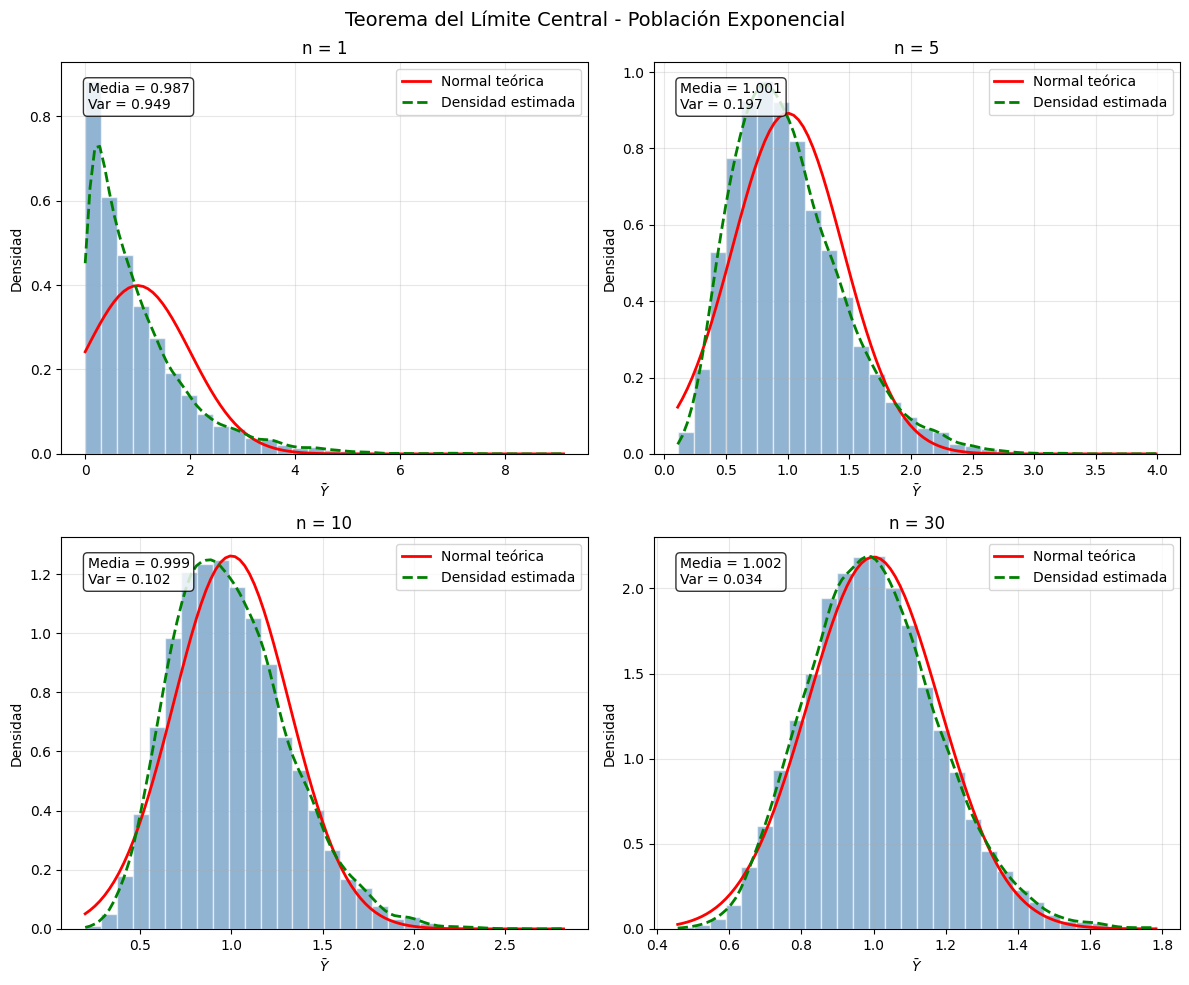

In [ ]:


# ============================================
#@title  **D. SIMULACIÓN DEL TEOREMA DEL LÍMITE CENTRAL - Python**
# Población no normal (distribución exponencial)
# ============================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, uniform, expon, binom, poisson

# Configuración
np.random.seed(123)
n_simulaciones = 10000
n_muestras = [1, 5, 10, 30]

# Función para generar medias muestrales de población exponencial
def generar_medias(n, n_sim, lambda_param=1):
    muestras = np.random.exponential(scale=1/lambda_param,
                                      size=(n_sim, n))
    return muestras.mean(axis=1)

# Parámetros de la exponencial (media = 1)
mu_poblacional = 1
sigma_poblacional = 1

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, n in enumerate(n_muestras):
    # Generar medias muestrales
    medias = generar_medias(n, n_simulaciones)

    # Histograma
    axes[idx].hist(medias, bins=30, density=True, alpha=0.6,
                   color='steelblue', edgecolor='white')

    # Curva normal teórica
    x_vals = np.linspace(medias.min(), medias.max(), 100)
    y_normal = norm.pdf(x_vals, loc=mu_poblacional,
                        scale=sigma_poblacional/np.sqrt(n))
    axes[idx].plot(x_vals, y_normal, 'r-', lw=2, label='Normal teórica')

    # Densidad estimada
    from scipy.stats import gaussian_kde
    kde = gaussian_kde(medias)
    axes[idx].plot(x_vals, kde(x_vals), 'g--', lw=2,
                   label='Densidad estimada')

    axes[idx].set_title(f'n = {n}')
    axes[idx].set_xlabel(r'$\bar{Y}$')
    axes[idx].set_ylabel('Densidad')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

    # Texto con estadísticas
    axes[idx].text(0.05, 0.95,
                   f'Media = {medias.mean():.3f}\nVar = {medias.var():.3f}',
                   transform=axes[idx].transAxes, verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('Teorema del Límite Central - Población Exponencial', fontsize=14)
plt.tight_layout()
plt.show()



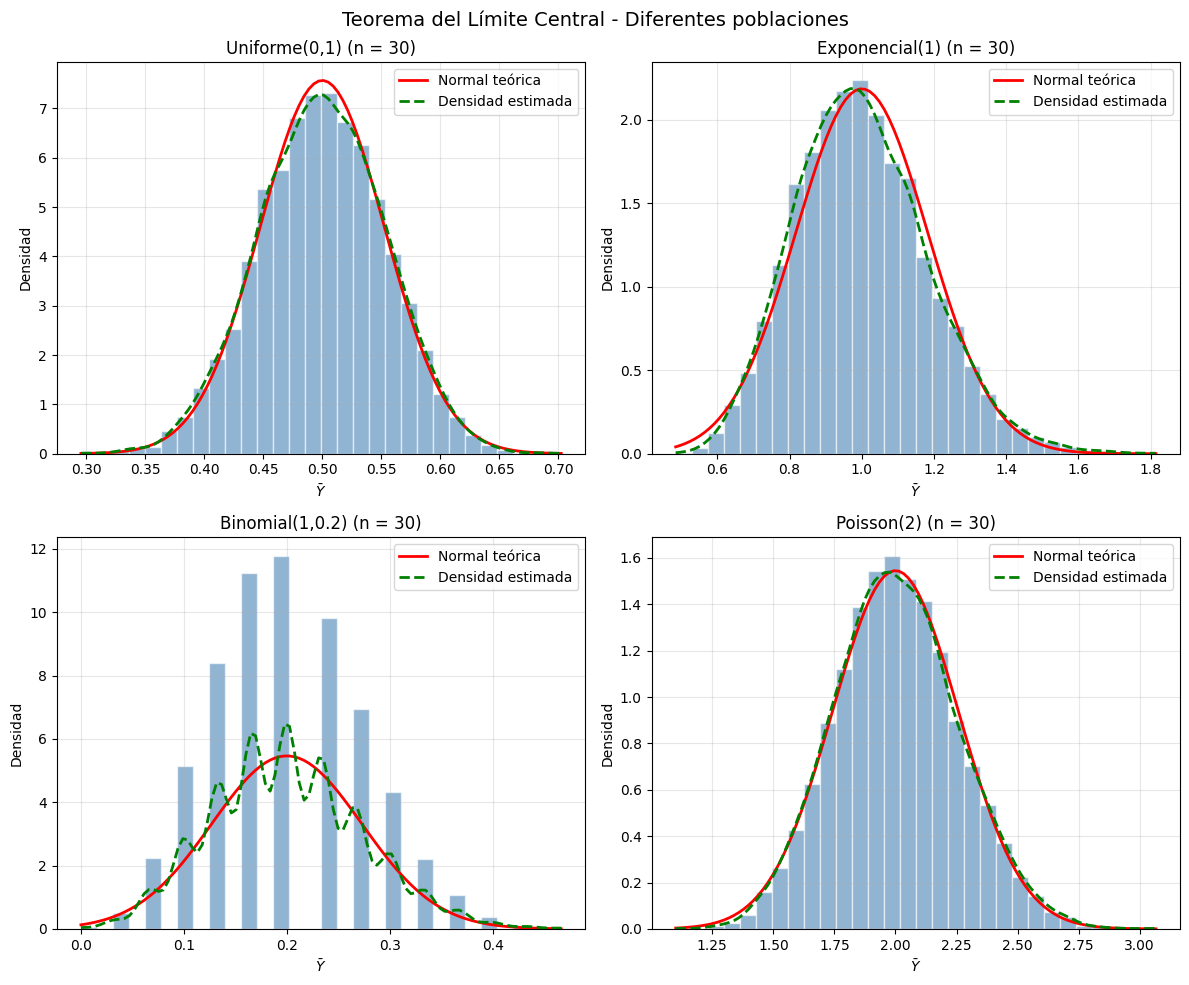

In [ ]:


# ============================================
# @title **E. COMPARACIÓN CON DIFERENTES POBLACIONES**
# ============================================

def generar_medias_poblacion(n, n_sim, distribucion, **kwargs):
    if distribucion == 'uniforme':
        muestras = np.random.uniform(0, 1, size=(n_sim, n))
        mu, sigma = 0.5, np.sqrt(1/12)
    elif distribucion == 'exponencial':
        muestras = np.random.exponential(scale=1, size=(n_sim, n))
        mu, sigma = 1, 1
    elif distribucion == 'binomial':
        p = kwargs.get('p', 0.2)
        muestras = np.random.binomial(1, p, size=(n_sim, n))
        mu, sigma = p, np.sqrt(p*(1-p))
    elif distribucion == 'poisson':
        lam = kwargs.get('lam', 2)
        muestras = np.random.poisson(lam, size=(n_sim, n))
        mu, sigma = lam, np.sqrt(lam)
    return muestras.mean(axis=1), mu, sigma

# Parámetros
n_sim = 10000
n = 30
distribuciones = {
    'Uniforme(0,1)': ('uniforme', {}),
    'Exponencial(1)': ('exponencial', {}),
    'Binomial(1,0.2)': ('binomial', {'p': 0.2}),
    'Poisson(2)': ('poisson', {'lam': 2})
}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, (nombre, (tipo, params)) in enumerate(distribuciones.items()):
    medias, mu, sigma = generar_medias_poblacion(n, n_sim, tipo, **params)

    axes[idx].hist(medias, bins=30, density=True, alpha=0.6,
                   color='steelblue', edgecolor='white')

    x_vals = np.linspace(medias.min(), medias.max(), 100)
    y_normal = norm.pdf(x_vals, loc=mu, scale=sigma/np.sqrt(n))
    axes[idx].plot(x_vals, y_normal, 'r-', lw=2, label='Normal teórica')

    kde = gaussian_kde(medias)
    axes[idx].plot(x_vals, kde(x_vals), 'g--', lw=2,
                   label='Densidad estimada')

    axes[idx].set_title(f'{nombre} (n = {n})')
    axes[idx].set_xlabel(r'$\bar{Y}$')
    axes[idx].set_ylabel('Densidad')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Teorema del Límite Central - Diferentes poblaciones', fontsize=14)
plt.tight_layout()
plt.show()



[⬆️ Volver al inicio](#inicio)

<a name="T3"></a>
## **5.3. INTERVALOS DE CONFIANZA PARA LA MEDIA**


In [ ]:


# ============================================
# @title **A. INTERVALOS DE CONFIANZA PARA LA MEDIA**
# ============================================
# CONTEXTO: Control de calidad en una fábrica
# Objetivo: Estimar el peso promedio real de los productos
# ============================================
%%R
# Parámetros conocidos
n <- 30                    # Tamaño de muestra
mu_verdadera <- 100        # Peso promedio real (desconocido en la práctica)
sigma <- 15                # Desviación estándar poblacional (conocida por experiencia)
confianza <- 0.95          # Nivel de confianza

# ============================================
# PARTE 1: CONSTRUCCIÓN DEL INTERVALO DE CONFIANZA
# ============================================

# Generar una muestra aleatoria (simulación del proceso de muestreo)
set.seed(456)              # Semilla para reproducibilidad
muestra <- rnorm(n, mean = mu_verdadera, sd = sigma)

# Estadísticos muestrales
media_muestral <- mean(muestra)
desv_muestral <- sd(muestra)
error_estandar <- desv_muestral / sqrt(n)

# Valor crítico de la distribución t
t_valor <- qt((1 + confianza)/2, df = n - 1)

# Intervalo de confianza
ic_inferior <- media_muestral - t_valor * error_estandar
ic_superior <- media_muestral + t_valor * error_estandar

# Presentación de resultados
cat("============================================\n")
cat("     INTERVALO DE CONFIANZA PARA LA MEDIA\n")
cat("============================================\n")
cat("Tamaño de muestra (n):", n, "\n")
cat("Media muestral (ȳ):", round(media_muestral, 2), "gramos\n")
cat("Desviación estándar muestral (s):", round(desv_muestral, 2), "gramos\n")
cat("Error estándar (s/√n):", round(error_estandar, 2), "gramos\n")
cat("Valor crítico t (95%):", round(t_valor, 4), "\n")
cat("Margen de error:", round(t_valor * error_estandar, 2), "gramos\n")
cat("\n🔍 INTERVALO DE CONFIANZA DEL 95%:\n")
cat("   [", round(ic_inferior, 2), ",", round(ic_superior, 2), "] gramos\n")
cat("\n📌 INTERPRETACIÓN:\n")
cat("   Con un 95% de confianza, el peso promedio real de\n")
cat("   todos los productos fabricados en la línea se encuentra\n")
cat("   entre", round(ic_inferior, 2), "y", round(ic_superior, 2), "gramos.\n")

# ============================================
# PARTE 2: SIMULACIÓN DE LA COBERTURA DEL INTERVALO
# ============================================

cat("\n============================================\n")
cat("  SIMULACIÓN DE LA COBERTURA DEL INTERVALO\n")
cat("============================================\n")
cat("A continuación se simulan 100 muestras diferentes\n")
cat("para evaluar qué porcentaje de los intervalos\n")
cat("construidos contienen al verdadero valor μ.\n\n")

n_sim <- 100                # Número de muestras a simular
n_muestra <- 30             # Tamaño de cada muestra
t_valor_sim <- qt((1 + confianza)/2, df = n_muestra - 1)

# Almacenar resultados de la simulación
contiene_mu <- logical(n_sim)
ic_inferiores <- numeric(n_sim)
ic_superiores <- numeric(n_sim)

# Simulación
for (i in 1:n_sim) {
  # Generar muestra aleatoria
  muestra_i <- rnorm(n_muestra, mean = mu_verdadera, sd = sigma)

  # Calcular estadísticos
  media_i <- mean(muestra_i)
  desv_i <- sd(muestra_i)
  ee_i <- desv_i / sqrt(n_muestra)

  # Construir intervalo
  ic_inferiores[i] <- media_i - t_valor_sim * ee_i
  ic_superiores[i] <- media_i + t_valor_sim * ee_i

  # Verificar si contiene a μ
  contiene_mu[i] <- (ic_inferiores[i] <= mu_verdadera &
                     ic_superiores[i] >= mu_verdadera)
}

# Calcular cobertura observada
cobertura <- mean(contiene_mu) * 100

cat("Cobertura observada:", round(cobertura, 1), "%\n")
cat("Cobertura teórica esperada:", confianza * 100, "%\n\n")



     INTERVALO DE CONFIANZA PARA LA MEDIA
Tamaño de muestra (n): 30 
Media muestral (ȳ): 103.48 gramos
Desviación estándar muestral (s): 17.34 gramos
Error estándar (s/√n): 3.17 gramos
Valor crítico t (95%): 2.0452 
Margen de error: 6.48 gramos

🔍 INTERVALO DE CONFIANZA DEL 95%:
   [ 97 , 109.95 ] gramos

📌 INTERPRETACIÓN:
   Con un 95% de confianza, el peso promedio real de
   todos los productos fabricados en la línea se encuentra
   entre 97 y 109.95 gramos.

  SIMULACIÓN DE LA COBERTURA DEL INTERVALO
A continuación se simulan 100 muestras diferentes
para evaluar qué porcentaje de los intervalos
construidos contienen al verdadero valor μ.

Cobertura observada: 94 %
Cobertura teórica esperada: 95 %



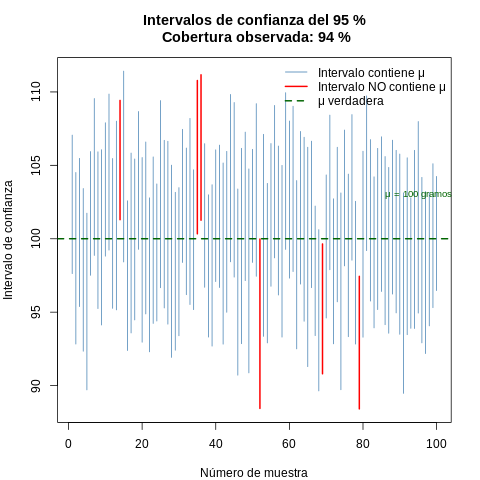

In [ ]:
%%R
# ============================================
# @title  **C. VISUALIZACIÓN DE INTERVALOS DE CONFIANZA**
# ============================================

# Configurar área de gráfico
par(mar = c(4, 4, 4, 2))

# Gráfico de intervalos de confianza
plot(1:n_sim, ic_inferiores, type = "n",
     xlab = "Número de muestra", ylab = "Intervalo de confianza",
     ylim = range(c(ic_inferiores, ic_superiores)),
     main = paste("Intervalos de confianza del", confianza*100, "%\n",
                  "Cobertura observada:", round(cobertura, 1), "%"),
     sub = "Los intervalos en rojo NO contienen el verdadero valor μ")

# Dibujar cada intervalo
for (i in 1:n_sim) {
  if (contiene_mu[i]) {
    segments(i, ic_inferiores[i], i, ic_superiores[i], col = "steelblue", lwd = 1)
  } else {
    segments(i, ic_inferiores[i], i, ic_superiores[i], col = "red", lwd = 2)
  }
}

# Línea horizontal para el valor verdadero de μ
abline(h = mu_verdadera, col = "darkgreen", lwd = 2, lty = 2)

# Leyenda
legend("topright",
       legend = c("Intervalo contiene μ", "Intervalo NO contiene μ", "μ verdadera"),
       col = c("steelblue", "red", "darkgreen"),
       lwd = c(1, 2, 2),
       lty = c(1, 1, 2),
       bty = "n")

# Agregar texto con el valor de μ
text(n_sim - 5, mu_verdadera + 3,
     labels = paste("μ =", mu_verdadera, "gramos"),
     col = "darkgreen", cex = 0.8)

Media muestral: 102.96
Desviación estándar muestral: 14.32
IC 95%: [97.62, 108.31]


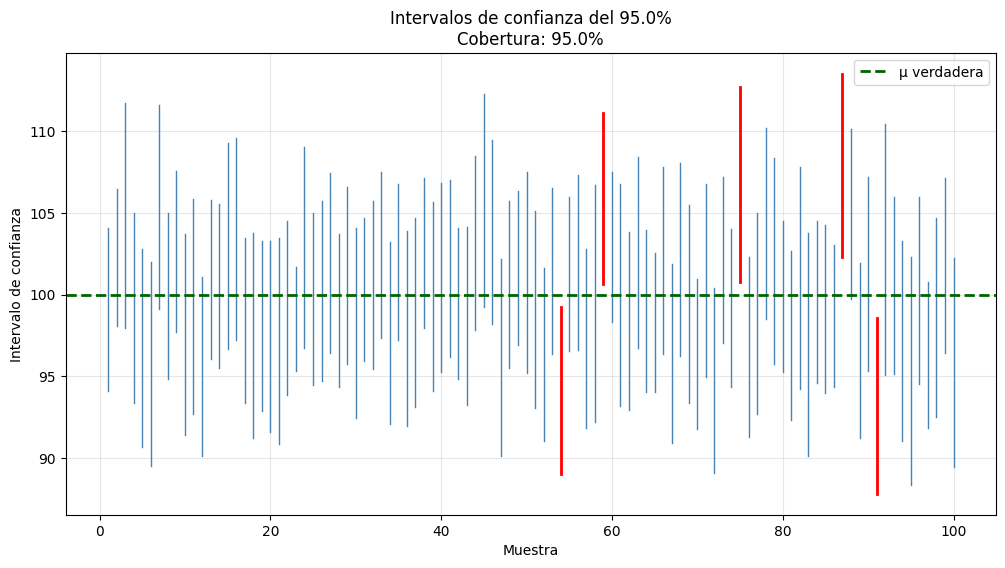

In [ ]:


# ============================================
# @title **D. INTERVALOS DE CONFIANZA PARA LA MEDIA**
# ============================================

import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# Generar una muestra
np.random.seed(456)
n = 30
mu_verdadera = 100
sigma = 15
muestra = np.random.normal(mu_verdadera, sigma, n)

# Estadísticos
media_muestral = np.mean(muestra)
desv_muestral = np.std(muestra, ddof=1)
error_estandar = desv_muestral / np.sqrt(n)

# Intervalo de confianza del 95%
confianza = 0.95
t_valor = stats.t.ppf((1 + confianza)/2, df=n-1)
ic_inferior = media_muestral - t_valor * error_estandar
ic_superior = media_muestral + t_valor * error_estandar

print(f"Media muestral: {media_muestral:.2f}")
print(f"Desviación estándar muestral: {desv_muestral:.2f}")
print(f"IC 95%: [{ic_inferior:.2f}, {ic_superior:.2f}]")

# ============================================
# VISUALIZACIÓN DE INTERVALOS DE CONFIANZA
# ============================================

# Simulación de múltiples muestras
n_sim = 100
n_muestra = 30
confianza = 0.95
t_valor = stats.t.ppf((1 + confianza)/2, df=n_muestra-1)

# Almacenar resultados
ic_inferiores = []
ic_superiores = []
contiene_mu = []

for i in range(n_sim):
    muestra_i = np.random.normal(mu_verdadera, sigma, n_muestra)
    media_i = np.mean(muestra_i)
    desv_i = np.std(muestra_i, ddof=1)
    ee_i = desv_i / np.sqrt(n_muestra)

    ic_inf = media_i - t_valor * ee_i
    ic_sup = media_i + t_valor * ee_i

    ic_inferiores.append(ic_inf)
    ic_superiores.append(ic_sup)
    contiene_mu.append(ic_inf <= mu_verdadera <= ic_sup)

# Convertir a arrays
ic_inferiores = np.array(ic_inferiores)
ic_superiores = np.array(ic_superiores)
contiene_mu = np.array(contiene_mu)

# Gráfico
fig, ax = plt.subplots(figsize=(12, 6))

for i in range(n_sim):
    color = 'steelblue' if contiene_mu[i] else 'red'
    ax.plot([i+1, i+1], [ic_inferiores[i], ic_superiores[i]],
            color=color, lw=1 if contiene_mu[i] else 2)

ax.axhline(mu_verdadera, color='darkgreen', lw=2, linestyle='--',
           label='μ verdadera')
ax.set_xlabel('Muestra')
ax.set_ylabel('Intervalo de confianza')
ax.set_title(f'Intervalos de confianza del {confianza*100}%\n'
             f'Cobertura: {np.mean(contiene_mu)*100:.1f}%')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()


[⬆️ Volver al inicio](#inicio)